# Diagnostic Churn Analysis

## Objective

The objective of this analysis is to identify the key factors associated with customer churn by examining demographic, geographic, financial, and engagement characteristics. The findings will help identify high-risk customer segments and support data-driven retention strategies.

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("ggplot")
sns.set_palette("Set2")

df = pd.read_csv('../data/cleaned_bank_churn.csv')

# 1. Geography vs Customer Churn

### Business Question

Does customer churn vary across different geographic regions?

In [44]:
geo_churn = (
    df.groupby('Geography')['Exited']
    .mean()
    .sort_values(ascending=False)*100 )

print(geo_churn)

Geography
Germany    32.443204
Spain      16.673395
France     16.154767
Name: Exited, dtype: float64


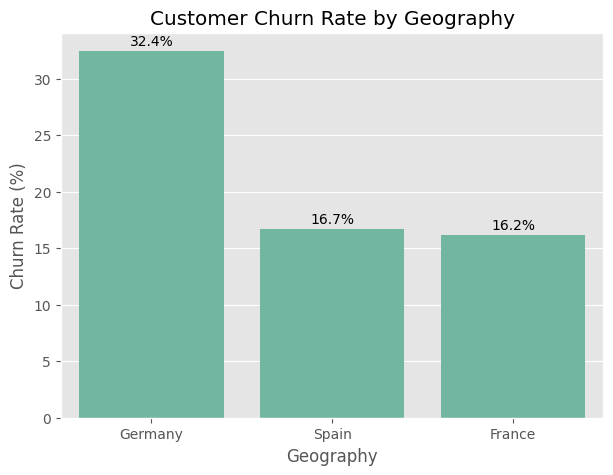

In [70]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=geo_churn.index,
    y=geo_churn.values
)

plt.title("Customer Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")

for i, v in enumerate(geo_churn.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.savefig(
    "../data/geography_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Finding

Germany records the highest churn rate (32.44%), nearly twice that of France and Spain, indicating that Germany represents the bank's highest regional churn risk.

### Business Implication

Customer retention initiatives should prioritize the German market because improvements there have the greatest potential to reduce overall customer attrition.

# 2. Gender vs Customer Churn

### Business Question

Does customer churn differ between male and female customers?

In [46]:
gender_churn = (df.groupby('Gender')['Exited'].mean().sort_values(ascending=False)*100)

print(gender_churn)

Gender
Female    25.071539
Male      16.455928
Name: Exited, dtype: float64


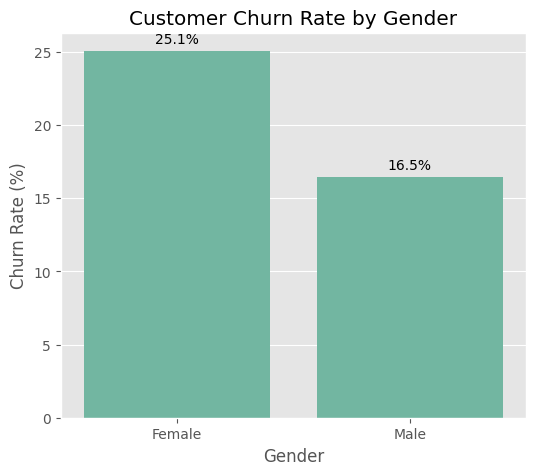

In [69]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=gender_churn.index,
    y=gender_churn.values
)

plt.title("Customer Churn Rate by Gender")
plt.ylabel("Churn Rate (%)")

for i, v in enumerate(gender_churn.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.savefig(
    "../data/gender_churn.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

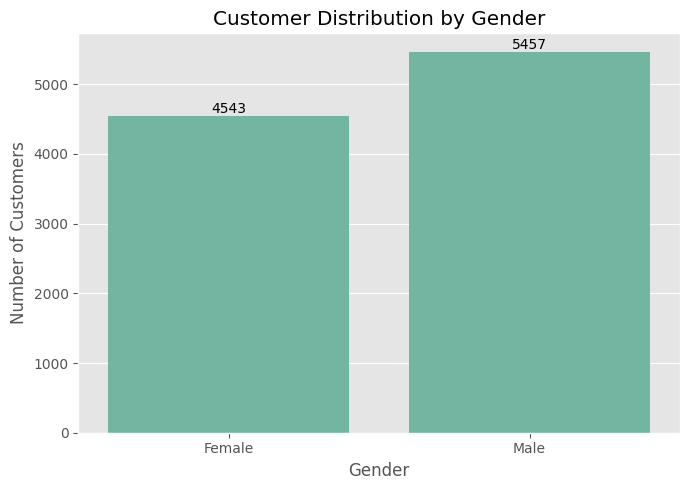

In [48]:
plt.figure(figsize=(7,5))

ax=sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Customer Distribution by Gender")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Business Implication

The higher churn observed among female customers suggests that customer experience, product offerings, or service expectations may differ across genders and warrant further investigation.

# 3. Age Group vs Customer Churn

### Business Question

Which age group exhibits the highest customer churn?

In [49]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18,30,45,60,100],
    labels=["18-30","31-45","46-60","60+"],
    include_lowest=True
)
age_churn = (
    df.groupby("Age_Group", observed=False)["Exited"]
      .mean()
      .mul(100)
)

age_churn

Age_Group
18-30     7.520325
31-45    15.740584
46-60    51.123254
60+      24.784483
Name: Exited, dtype: float64

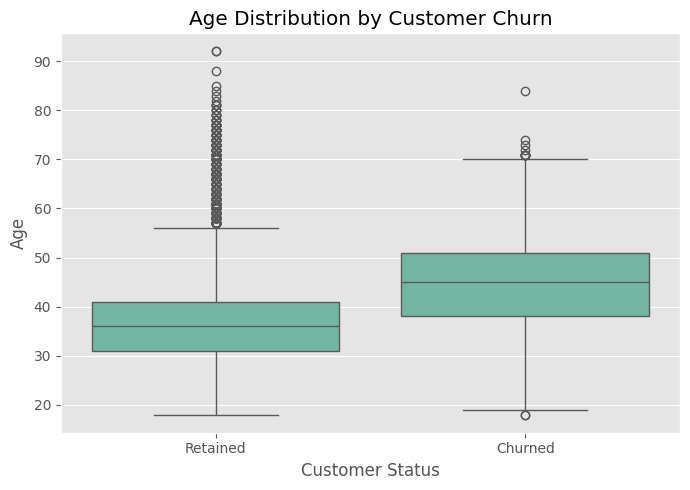

In [68]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x="Exited",
    y="Age",
    data=df
)

plt.title("Age Distribution by Customer Churn")
plt.xlabel("Customer Status")
plt.ylabel("Age")

plt.xticks([0, 1], ["Retained", "Churned"])

plt.tight_layout()

plt.savefig(
    "../data/age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

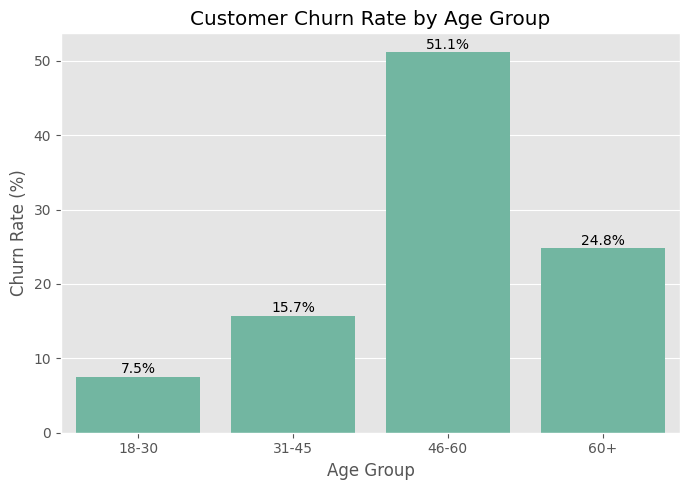

In [51]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=age_churn.index,
    y=age_churn.values
)

plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

for i, v in enumerate(age_churn.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()

### Business Implication

Customers aged 46–60 should be considered a priority segment for proactive retention campaigns.

# 4. Customer Activity vs Churn

### Business Question

Does customer activity influence customer retention?

In [52]:
activity = (
    df.groupby("IsActiveMember")["Exited"]
      .mean()
      .mul(100)
)

activity

IsActiveMember
0    26.850897
1    14.269074
Name: Exited, dtype: float64

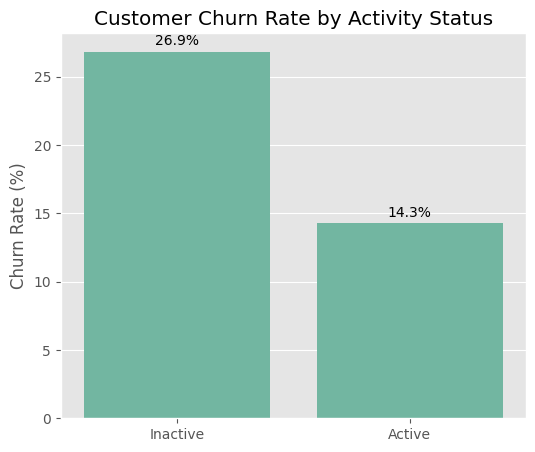

In [53]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=["Inactive","Active"],
    y=activity.values
)

plt.title("Customer Churn Rate by Activity Status")
plt.ylabel("Churn Rate (%)")

for i, v in enumerate(activity.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center")

plt.show()

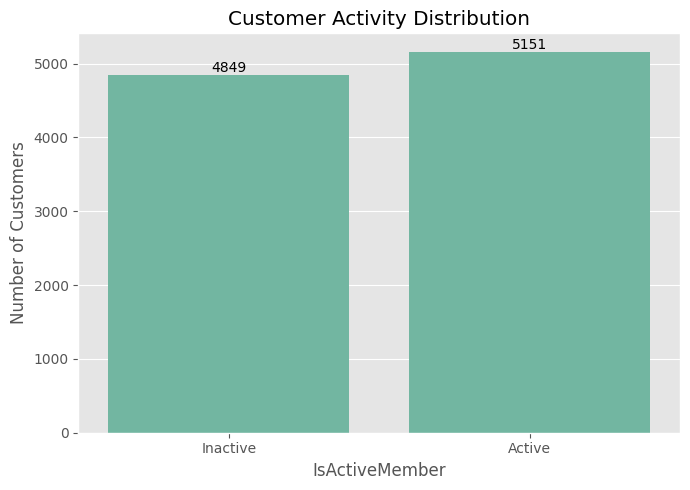

In [54]:
plt.figure(figsize=(7,5))

ax=sns.countplot(
    data=df,
    x="IsActiveMember"
)

plt.xticks([0,1],["Inactive","Active"])

plt.title("Customer Activity Distribution")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Business implication:

Increasing customer engagement may significantly reduce churn, making engagement programs an effective retention strategy.


# 5. Balance Segment vs Churn

### Business Question

Do customers with different account balance levels exhibit different churn behavior?

In [55]:
balance_bins = [-1, 0, 50000, 100000, 150000, float('inf')]
balance_labels = ["Zero Balance", "Low Balance", "Medium Balance", "High Balance", "Very High Balance"]

df["Balance_Group"] = pd.cut(
    df["Balance"],
    bins=balance_bins,
    labels=balance_labels,
    include_lowest=True
)

balance_churn = (
    df.groupby("Balance_Group", observed=False)["Exited"]
      .mean()
      .mul(100)
)

balance_churn

Balance_Group
Zero Balance         13.823611
Low Balance          34.666667
Medium Balance       19.880716
High Balance         25.770235
Very High Balance    23.116615
Name: Exited, dtype: float64

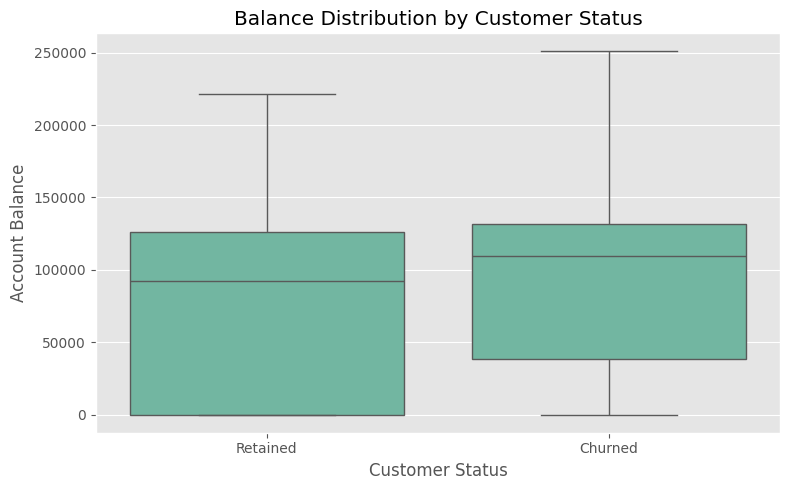

In [56]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Exited",
    y="Balance",
    data=df
)

plt.xticks([0,1],["Retained","Churned"])

plt.title("Balance Distribution by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Account Balance")

plt.tight_layout()
plt.show()

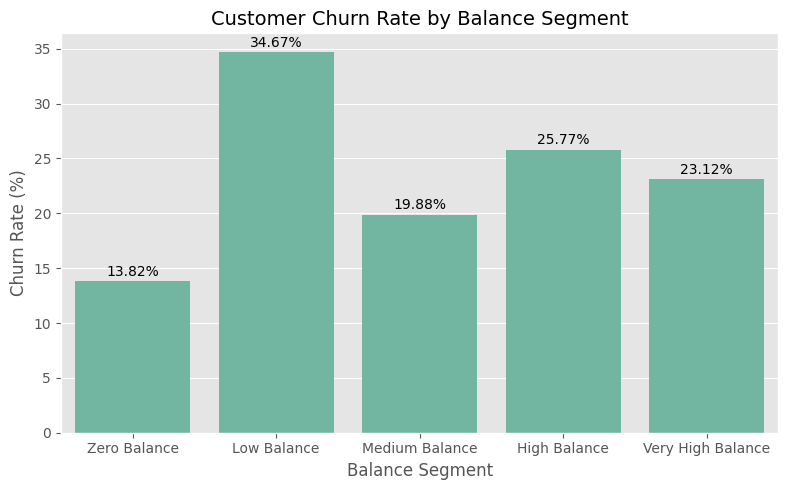

In [57]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=balance_churn.index,
    y=balance_churn.values
)

plt.title("Customer Churn Rate by Balance Segment", fontsize=14)
plt.xlabel("Balance Segment")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(balance_churn.values):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

# 6. Credit Score vs Churn

### Business Question

Is customer creditworthiness associated with churn?

In [58]:
df["Credit_Group"] = pd.cut(
    df["CreditScore"],
    bins=[300,580,700,850],
    labels=["Low","Medium","High"]
)
credit_churn = (
    df.groupby("Credit_Group", observed=False)["Exited"]
      .mean()
      .mul(100)
)

credit_churn

Credit_Group
Low       22.147931
Medium    19.772879
High      19.865212
Name: Exited, dtype: float64

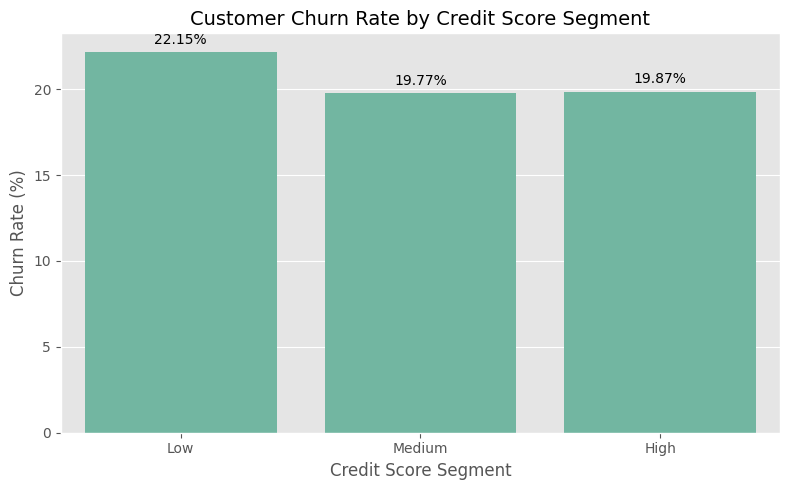

In [59]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=credit_churn.index,
    y=credit_churn.values
)

plt.title("Customer Churn Rate by Credit Score Segment", fontsize=14)
plt.xlabel("Credit Score Segment")
plt.ylabel("Churn Rate (%)")

for i, value in enumerate(credit_churn.values):
    ax.text(i, value + 0.5, f"{value:.2f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

### Business Implication

Credit score appears to have a limited influence on churn compared with engagement and demographic factors.

# 7. Number of Products vs Churn

### Business Question

Does the number of banking products influence customer retention?

In [60]:
df["NumOfProducts"].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [61]:
products = (
    df.groupby("NumOfProducts")["Exited"]
      .mean()
      .mul(100)
)

products

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64

### Business Implication

Customers holding only one product represent an opportunity for cross-selling, while the extremely high churn observed among customers with three or four products should be validated due to likely small sample sizes.

# Correlation Heatmap

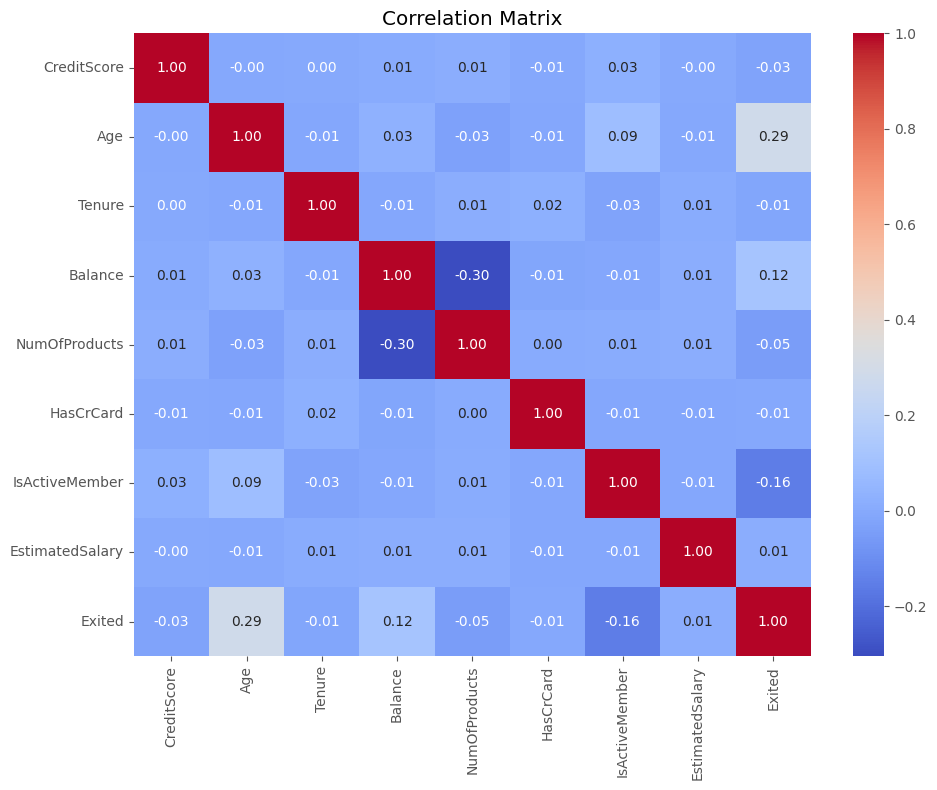

In [67]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    "../data/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Executive Summary

The diagnostic analysis identified several factors associated with customer churn.

### Key Findings

- Germany exhibits the highest customer churn rate among all geographic regions.
- Female customers churn at a higher rate than male customers.
- Customers aged 46–60 represent the highest-risk demographic segment.
- Customer inactivity is strongly associated with churn.
- Customers maintaining two banking products demonstrate the strongest retention.
- Credit score has comparatively limited influence on customer churn.

### Conclusion

The analysis indicates that customer churn is primarily associated with demographic characteristics and customer engagement rather than financial variables alone. These findings provide the foundation for developing segmentation-driven retention strategies in the next phase of the project.